In [1]:
import os

os.environ["KERAS_BACKEND"] = "torch"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import torch
import numpy as np
import albumentations as A

import warnings

warnings.filterwarnings(
    "ignore",
    message="Gradients do not exist for variables",
    module="keras.src.optimizers.base_optimizer",
)

from pathlib import Path
from typing import Sequence

from PIL import Image
from torch.utils.data import Dataset, DataLoader

from agx_core.transforms import BrightnessAndContrast, Deskew


class UnlabeledImageDataset(Dataset):
    def __init__(self, root_dir: Path, cond_shape: Sequence[int], transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.cond_shape = cond_shape
        # Get list of all image file names in the folder
        self.image_files = list(root_dir.glob("*.bmp"))

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        image = Image.open(img_name).convert("L")

        if self.transform:
            image = self.transform(image=np.array(image))
            image = image["image"][..., np.newaxis]

        condition = np.ones(self.cond_shape, dtype=np.float32)

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        image = torch.tensor(image, device=device)
        return (image, torch.tensor(condition, device=device)), image


# def train_transforms(img_size, mean=[0.7], std=[0.4]):
def train_transforms(img_size, mean=[0.5], std=[0.5]):
    return A.Compose(
        [
            Deskew(),
            A.Pad((25,25), 255),
            BrightnessAndContrast(),
            A.InvertImg(1),
            A.Resize(img_size, img_size),
            A.Affine(scale=(0.9, 0.95), rotate=(-90, 90), shear=(5, 5), p=0.5),
            A.RandomRotate90(0.5),
            A.GaussianBlur(blur_range=(1, 3), p=0.3),
            A.Normalize(mean=mean, std=std),
        ]
    )


# def valid_transforms(img_size, mean=[0.7], std=[0.4]):
def valid_transforms(img_size, mean=[0.5], std=[0.5]):
    return A.Compose(
        [
            Deskew(),
            A.Pad((25,25), 255),
            BrightnessAndContrast(),
            A.InvertImg(1),
            A.Resize(img_size, img_size),
            A.Normalize(mean=mean, std=std),
        ]
    )

In [ ]:
from agx_core.models.reversed_autoencoder import MobileNetV3SmallEncoder, MobileNetV3SmallDecoder
from agx_torch.models.reversed_autoencoder.model import ReversedAutoencoder
from agx_torch.models.reversed_autoencoder.layers import Reparameterization

img_size = 224
res = img_size // 2**5

img_shape = (None, img_size, img_size, 1)
cond_shape = (None, res, res, 1)

rep = Reparameterization()
enc = MobileNetV3SmallEncoder(latent_size=256, progressive=False)
dec = MobileNetV3SmallDecoder(target_shape=img_shape[1:], progressive=False)

print(img_shape, cond_shape)

(None, 224, 224, 1) (None, 7, 7, 1)


In [3]:
# import keras
# x = keras.random.normal((1, 224, 224, 1))
# c = keras.random.normal((1, 7, 7, 1))

# x_resized = keras.ops.image.resize(x, enc.current_input_size())

# (mean, logvar), embeds = enc([x_resized, c])
# z = rep([mean, logvar])

In [4]:
train_path = Path("../data/products/LaTuaPastaGlassJars/Clean/train/")
valid_path = Path("../data/products/LaTuaPastaGlassJars/Clean/val/")
test_path = Path("../data/products/LaTuaPastaGlassJars/Test/images/train/")

ds_train = UnlabeledImageDataset(
    train_path, transform=train_transforms(img_size), cond_shape=cond_shape[1:]
)
ds_valid = UnlabeledImageDataset(
    valid_path, transform=valid_transforms(img_size), cond_shape=cond_shape[1:]
)
ds_test = UnlabeledImageDataset(
    test_path, transform=valid_transforms(img_size), cond_shape=cond_shape[1:]
)

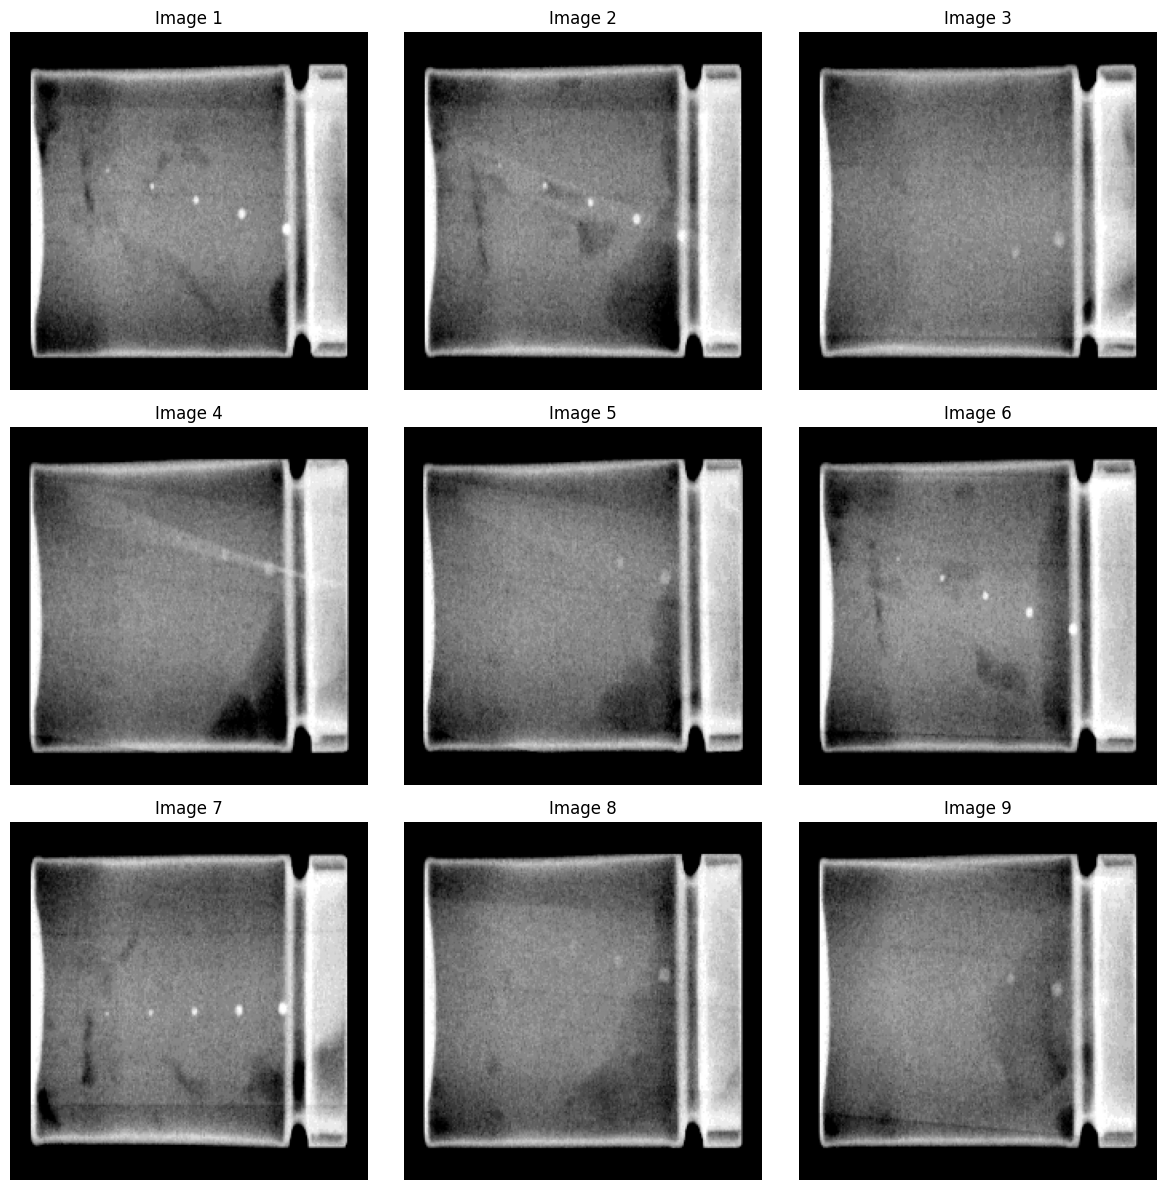

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for idx, ax in enumerate(axes.flat):
    X, y = ds_test[idx]
    image = X[0].cpu().numpy()
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Image {idx + 1}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [6]:
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint

from agx_core.models.reversed_autoencoder.callbacks import (
    AdversarialEquilibriumCallback,
    ProgressiveGrowingCallback,
)

ra = ReversedAutoencoder(enc, dec, beta_kld=0.1, freeze_backbone=False)
ra.build([img_shape, cond_shape])
ra.compile(Adam(learning_rate=7e-6), Adam(learning_rate=1e-4))

callbacks = [
    AdversarialEquilibriumCallback(0.3, -0.5, min_pause_steps=100),
    # ProgressiveGrowingCallback(750, 750),
    ModelCheckpoint(
        filepath="ra_mbnetv3.best.keras",
        monitor="val_loss_rec",
        mode="min",
        save_best_only=True,
        verbose=1,
    ),
]

ra.summary()


loader_train = DataLoader(ds_train, batch_size=6, shuffle=True)
loader_valid = DataLoader(ds_valid, batch_size=6)

Model: "reversed_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mbnetv3_encoder                 │ (((None, 7, 7, 512),   │     1,529,528 │
│ (MobileNetV3SmallEncoder)       │ (None, 7, 7, 512)),    │               │
│                                 │ [(None, 112, 112, 16), │               │
│                                 │ (None, 56, 56, 16),    │               │
│                                 │ (None, 28, 28, 24),    │               │
│                                 │ (None, 14, 14, 40),    │               │
│                                 │ (None, 7, 7, 96)])     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mbnetv3_decoder                 │ (None, 224, 224, 1)    │     1,620,053 │
│ (MobileNetV3SmallDecoder)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reparameterization              │ (None, 7, 7, 512)      │             0 │
│ (Reparameterization)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,208,659 (23.68 MB)

 Trainable params: 3,122,557 (11.91 MB)

 Non-trainable params: 27,024 (105.56 KB)

 Optimizer params: 3,059,078 (11.67 MB)

In [7]:
history = ra.fit(loader_train, validation_data=loader_valid, epochs=1000, callbacks=callbacks, verbose=2)

Epoch 1/1000

Epoch 1: val_loss_rec improved from None to 0.47687, saving model to ra_mbnetv3.best.keras

Epoch 1: finished saving model to ra_mbnetv3.best.keras
34/34 - 23s - 668ms/step - diff_kld: 0.0031 - elbo_fake: -3.2144e-02 - elbo_real: -5.2873e-01 - elbo_rec: -3.2465e-02 - expelbo_fake: 0.9689 - expelbo_rec: 0.9686 - kld_fake: 0.3214 - kld_real: 0.3199 - kld_rec: 0.3246 - loss_dec: 2.6477 - loss_embed: 1.7841 - loss_enc: 1.4977 - loss_rec: 0.4967 - val_diff_kld: 1.1730e-10 - val_elbo_fake: -9.1605e-05 - val_elbo_real: -4.7696e-01 - val_elbo_rec: -9.1605e-05 - val_expelbo_fake: 0.9999 - val_expelbo_rec: 0.9999 - val_kld_fake: 9.1605e-04 - val_kld_real: 9.1605e-04 - val_kld_rec: 9.1605e-04 - val_loss_dec: 2.0692 - val_loss_embed: 1.5921 - val_loss_enc: 1.4769 - val_loss_rec: 0.4769
Epoch 2/1000


KeyboardInterrupt: 

In [ ]:
ra.save("ra_mbnetv3.model.keras")

In [ ]:
import pandas as pd

df = pd.DataFrame.from_dict(history.history)

hist_file = Path("history.csv")
if hist_file.exists():
    hist = pd.read_csv(hist_file)
    df.index += len(hist)
    hist = pd.concat([hist, df])
    # hist.to_csv(hist_file, index=False)
else:
    df.to_csv(hist_file, index=False)
    hist = df
hist.tail()


In [ ]:
import keras
import matplotlib.pyplot as plt

ra = keras.models.load_model("ra_mbnetv3.best.keras", safe_mode=False)
while not ra.decoder.is_fully_grown:
    ra.encoder.grow()
    ra.encoder.alpha = 1
    ra.decoder.grow()
    ra.decoder.alpha = 1


fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for idx, ax in enumerate(axes.flat):
    (I, C), y = ds_train[idx]
    rec = ra([I[np.newaxis, ...], C[np.newaxis, ...]])
    ax.imshow(rec.cpu().detach().numpy()[0], cmap="gray")
    ax.set_title(f"Image {idx + 1}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

fig, ax = plt.subplots(figsize=(21, 14))

# Adjust val_loss_embed, forgot to update validation scaling
hist[["kld_fake", "kld_real"]].plot(ax=ax)

In [ ]:
with torch.device("cpu"):
    ra.eval()
    I = torch.rand((1, *img_shape[1:]))
    C = torch.rand((1, *cond_shape[1:]))
    Z = torch.rand((1, *cond_shape[1:3], 512))
    
    import keras
    i_ = keras.Input(img_shape[1:])
    c_ = keras.Input(cond_shape[1:])

    (mean, logvar), _ = ra.encoder([i_, c_])
    z = ra.reparameterize([mean, logvar])
    rec = ra.decoder([z, c_])

    model = keras.Model(inputs=[i_, c_], outputs=[rec, mean, logvar], name="reversed_autoencoder")
    model.training = False
    model.eval()

    torch.onnx.export(
        model,
        ([I, C],),
        "model.onnx",
        input_names=["image", "condition"],
        output_names=["reconstruction", "mean", "logvar"],
    )

In [ ]:
import matplotlib.pyplot as plt

from agx_core.helpers import _channel_axis
from keras import ops

def kl_divergence(mean, logvar):
    return 0.5 * ops.sum(
        ops.square(mean) + ops.exp(logvar) - logvar - 1.0,
        axis=_channel_axis(),
    )

fig, axes = plt.subplots(5, 3, figsize=(12, 20))

for idx in range(5):
    (I, C), y = ds_test[idx]
    rec = ra_best([I[np.newaxis, ...], C[np.newaxis, ...]]).cpu().detach().numpy()[0][0]
    (mean, logvar), _ = ra_best.encoder([I[np.newaxis, ...], C[np.newaxis, ...]])
    kld = kl_divergence(mean, logvar).cpu().detach().numpy()[0]
    I = I[0].cpu().detach().numpy()
    D = np.square(I - rec)
    axes.flat[3 * idx].imshow(rec, cmap="gray")
    axes.flat[3 * idx + 1].imshow(I, cmap="gray")
    axes.flat[3 * idx + 2].imshow(D, cmap="gray")
    axes.flat[3 * idx].axis("off")
    axes.flat[3 * idx + 1].axis("off")
    axes.flat[3 * idx + 2].axis("off")

plt.tight_layout()
plt.show()